# Install required packages

In [25]:
!pip install -qq numpy pandas matplotlib scikit-learn nltk

# Import libraries

In [26]:
import re
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter, defaultdict
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

import nltk
from nltk.corpus import gutenberg

# Download Gutenberg corpus

In [27]:
nltk.download("gutenberg")

[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!


True

# Load Genesis and Shakespeare

In [28]:
genesis_raw = gutenberg.raw("bible-kjv.txt")

shakespeare_files = [f for f in gutenberg.fileids() if "shakespeare" in f.lower()]
shakespeare_raw = "\n".join([gutenberg.raw(f) for f in shakespeare_files])

print("Genesis length:", len(genesis_raw))
print("Shakespeare length:", len(shakespeare_raw))
print("Shakespeare files:", shakespeare_files)

Genesis length: 4332554
Shakespeare length: 375544
Shakespeare files: ['shakespeare-caesar.txt', 'shakespeare-hamlet.txt', 'shakespeare-macbeth.txt']


# Clean the Genesis corpus

In [29]:
def clean_genesis_text(text):
    text = text.lower()

    # Keep only Genesis if entire Bible is present
    genesis_start = re.search(r"\bgenesis\b", text)
    exodus_start = re.search(r"\bexodus\b", text)

    if genesis_start and exodus_start and genesis_start.start() < exodus_start.start():
        text = text[genesis_start.start():exodus_start.start()]

    # Remove chapter and verse numbers like 1:1 or standalone numbers
    text = re.sub(r"\b\d+:\d+\b", " ", text)
    text = re.sub(r"\b\d+\b", " ", text)

    # Remove punctuation except apostrophes
    text = re.sub(r"[^a-z\s']", " ", text)

    # Normalize spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

genesis_clean = clean_genesis_text(genesis_raw)
print(genesis_clean[:1000])

genesis in the beginning god created the heaven and the earth and the earth was without form and void and darkness was upon the face of the deep and the spirit of god moved upon the face of the waters and god said let there be light and there was light and god saw the light that it was good and god divided the light from the darkness and god called the light day and the darkness he called night and the evening and the morning were the first day and god said let there be a firmament in the midst of the waters and let it divide the waters from the waters and god made the firmament and divided the waters which were under the firmament from the waters which were above the firmament and it was so and god called the firmament heaven and the evening and the morning were the second day and god said let the waters under the heaven be gathered together unto one place and let the dry land appear and it was so and god called the dry land earth and the gathering together of the waters called he sea

# Clean the Shakespeare corpus

In [30]:
def clean_shakespeare_text(text):
    text = text.lower()

    # Remove roman numerals often used in acts/scenes
    text = re.sub(r"\b[ivxlcdm]+\b", " ", text)

    # Remove punctuation except apostrophes
    text = re.sub(r"[^a-z\s']", " ", text)

    # Normalize spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

shakespeare_clean = clean_shakespeare_text(shakespeare_raw)
print(shakespeare_clean[:1000])

the tragedie of julius caesar by william shakespeare actus primus scoena prima enter flauius murellus and certaine commoners ouer the stage flauius hence home you idle creatures get you home is this a holiday what know you not being mechanicall you ought not walke vpon a labouring day without the signe of your profession speake what trade art thou car why sir a carpenter mur where is thy leather apron and thy rule what dost thou with thy best apparrell on you sir what trade are you cobl truely sir in respect of a fine workman am but as you would say a cobler mur but what trade art thou answer me directly cob a trade sir that hope may vse with a safe conscience which is indeed sir a mender of bad soules fla what trade thou knaue thou naughty knaue what trade cobl nay beseech you sir be not out with me yet if you be out sir can mend you mur what mean'st thou by that mend mee thou sawcy fellow cob why sir cobble you fla thou art a cobler art thou cob truly sir all that liue by is with the

# Save cleaned corpora

In [31]:
with open("cleaned_genesis.txt", "w", encoding="utf-8") as f:
    f.write(genesis_clean)

with open("cleaned_shakespeare.txt", "w", encoding="utf-8") as f:
    f.write(shakespeare_clean)

print("Saved cleaned_genesis.txt and cleaned_shakespeare.txt")

Saved cleaned_genesis.txt and cleaned_shakespeare.txt


# Tokenise

In [32]:
genesis_tokens = genesis_clean.split()
shakespeare_tokens = shakespeare_clean.split()

print("Genesis tokens:", len(genesis_tokens))
print("Shakespeare tokens:", len(shakespeare_tokens))
print("Genesis sample:", genesis_tokens[:20])
print("Shakespeare sample:", shakespeare_tokens[:20])

Genesis tokens: 38271
Shakespeare tokens: 66290
Genesis sample: ['genesis', 'in', 'the', 'beginning', 'god', 'created', 'the', 'heaven', 'and', 'the', 'earth', 'and', 'the', 'earth', 'was', 'without', 'form', 'and', 'void', 'and']
Shakespeare sample: ['the', 'tragedie', 'of', 'julius', 'caesar', 'by', 'william', 'shakespeare', 'actus', 'primus', 'scoena', 'prima', 'enter', 'flauius', 'murellus', 'and', 'certaine', 'commoners', 'ouer', 'the']


# Build vocabulary

In [33]:
def build_vocab(tokens, min_count=5, max_vocab=3000):
    counts = Counter(tokens)
    vocab = [word for word, count in counts.items() if count >= min_count]
    vocab = sorted(vocab, key=lambda w: counts[w], reverse=True)[:max_vocab]

    word_to_id = {word: idx for idx, word in enumerate(vocab)}
    id_to_word = {idx: word for word, idx in word_to_id.items()}

    return vocab, word_to_id, id_to_word, counts

gen_vocab, gen_word_to_id, gen_id_to_word, gen_counts = build_vocab(genesis_tokens, min_count=3, max_vocab=2000)
sha_vocab, sha_word_to_id, sha_id_to_word, sha_counts = build_vocab(shakespeare_tokens, min_count=5, max_vocab=3000)

print("Genesis vocab size:", len(gen_vocab))
print("Shakespeare vocab size:", len(sha_vocab))

Genesis vocab size: 1104
Shakespeare vocab size: 1474


# Build co-occurrence matrix

In [34]:
def build_cooccurrence_matrix(tokens, word_to_id, window_size=4):
    vocab_size = len(word_to_id)
    cooc = np.zeros((vocab_size, vocab_size), dtype=np.float32)

    token_ids = [word_to_id[w] for w in tokens if w in word_to_id]

    for center_i, center_id in enumerate(token_ids):
        left = max(0, center_i - window_size)
        right = min(len(token_ids), center_i + window_size + 1)

        for context_i in range(left, right):
            if context_i == center_i:
                continue

            context_id = token_ids[context_i]
            distance = abs(center_i - context_i)
            weight = 1.0 / distance
            cooc[center_id, context_id] += weight

    return cooc

gen_cooc = build_cooccurrence_matrix(genesis_tokens, gen_word_to_id, window_size=4)
sha_cooc = build_cooccurrence_matrix(shakespeare_tokens, sha_word_to_id, window_size=4)

print("Genesis co-occurrence shape:", gen_cooc.shape)
print("Shakespeare co-occurrence shape:", sha_cooc.shape)

Genesis co-occurrence shape: (1104, 1104)
Shakespeare co-occurrence shape: (1474, 1474)


# Convert co-occurrence matrix to PPMI matrix

In [35]:
def cooc_to_ppmi(cooc):
    total = np.sum(cooc)
    row_sums = np.sum(cooc, axis=1, keepdims=True)
    col_sums = np.sum(cooc, axis=0, keepdims=True)

    expected = row_sums @ col_sums / total

    with np.errstate(divide="ignore", invalid="ignore"):
        pmi = np.log((cooc * total) / (row_sums @ col_sums + 1e-10) + 1e-10)

    ppmi = np.maximum(pmi, 0)
    ppmi[np.isnan(ppmi)] = 0
    ppmi[np.isinf(ppmi)] = 0

    return ppmi

gen_ppmi = cooc_to_ppmi(gen_cooc)
sha_ppmi = cooc_to_ppmi(sha_cooc)

print("PPMI matrices built.")

PPMI matrices built.


# Reduce to embedding space

In [36]:
def build_embeddings_from_ppmi(ppmi_matrix, embedding_dim=50):
    pca = PCA(n_components=embedding_dim)
    embeddings = pca.fit_transform(ppmi_matrix)
    return embeddings, pca

gen_embeddings, gen_pca = build_embeddings_from_ppmi(gen_ppmi, embedding_dim=50)
sha_embeddings, sha_pca = build_embeddings_from_ppmi(sha_ppmi, embedding_dim=50)

print("Genesis embeddings shape:", gen_embeddings.shape)
print("Shakespeare embeddings shape:", sha_embeddings.shape)

Genesis embeddings shape: (1104, 50)
Shakespeare embeddings shape: (1474, 50)


# Helper function for nearest neighbors

In [37]:
def nearest_neighbors(word, embeddings, word_to_id, id_to_word, top_n=10):
    if word not in word_to_id:
        return []

    idx = word_to_id[word]
    vector = embeddings[idx].reshape(1, -1)

    sims = cosine_similarity(vector, embeddings)[0]
    nearest_ids = np.argsort(sims)[::-1][1:top_n+1]

    return [(id_to_word[i], float(sims[i])) for i in nearest_ids]

# Test Genesis semantic neighborhoods

In [38]:
genesis_test_words = ["god", "earth", "light", "man", "father", "dream"]

for word in genesis_test_words:
    print(f"\nGenesis neighbors for '{word}':")
    print(nearest_neighbors(word, gen_embeddings, gen_word_to_id, gen_id_to_word, top_n=8))


Genesis neighbors for 'god':
[('lord', 0.7538285851478577), ('hath', 0.6427894234657288), ('blessed', 0.5349439978599548), ('created', 0.5010501742362976), ('he', 0.4870757460594177), ('high', 0.4731898009777069), ('most', 0.4702976942062378), ('had', 0.4589076638221741)]

Genesis neighbors for 'earth':
[('waters', 0.7825425267219543), ('fowl', 0.582247257232666), ('heaven', 0.5787690877914429), ('ark', 0.5630149841308594), ('prevailed', 0.5609686374664307), ('abundantly', 0.5598160028457642), ('above', 0.5533321499824524), ('upon', 0.552529513835907)]

Genesis neighbors for 'light':
[('darkness', 0.7422083020210266), ('divide', 0.7102852463722229), ('lights', 0.7101980447769165), ('rule', 0.6393874883651733), ('firmament', 0.6115809679031372), ('rain', 0.6037513613700867), ('greater', 0.5767942070960999), ('seventh', 0.554272472858429)]

Genesis neighbors for 'man':
[('one', 0.5598241686820984), ('a', 0.5519604086875916), ('each', 0.5115602612495422), ('child', 0.48864632844924927), 

# Test Shakespeare semantic neighborhoods

In [39]:
shakespeare_test_words = ["king", "love", "death", "man", "heart", "night"]

for word in shakespeare_test_words:
    print(f"\nShakespeare neighbors for '{word}':")
    print(nearest_neighbors(word, sha_embeddings, sha_word_to_id, sha_id_to_word, top_n=8))


Shakespeare neighbors for 'king':
[('queene', 0.7133981585502625), ('lords', 0.7083150148391724), ('polonius', 0.6738747954368591), ('hamlet', 0.6516597270965576), ('rosincrance', 0.5957632660865784), ('laertes', 0.5842612981796265), ('guildensterne', 0.5781682729721069), ('qu', 0.5697380900382996)]

Shakespeare neighbors for 'love':
[]

Shakespeare neighbors for 'death':
[('in', 0.5515642762184143), ('his', 0.5457788109779358), ('of', 0.5352182984352112), ('fathers', 0.47428208589553833), ('by', 0.45591139793395996), ('and', 0.45554131269454956), ('thy', 0.4543636441230774), ('many', 0.44079676270484924)]

Shakespeare neighbors for 'man':
[('euery', 0.6324668526649475), ('a', 0.48945632576942444), ('an', 0.4874438941478729), ('one', 0.4787530303001404), ("that's", 0.4751003682613373), ('then', 0.4658084511756897), ('but', 0.4640195369720459), ('that', 0.4632120728492737)]

Shakespeare neighbors for 'heart':
[('thy', 0.5020450949668884), ('if', 0.46905839443206787), ('yet', 0.43425294

# Side-by-side comparison function

In [40]:
def compare_word_across_corpora(word_genesis, word_shakespeare):
    print(f"\nGenesis neighbors for '{word_genesis}':")
    print(nearest_neighbors(word_genesis, gen_embeddings, gen_word_to_id, gen_id_to_word, top_n=8))

    print(f"\nShakespeare neighbors for '{word_shakespeare}':")
    print(nearest_neighbors(word_shakespeare, sha_embeddings, sha_word_to_id, sha_id_to_word, top_n=8))

# Compare common ideas

In [41]:
compare_word_across_corpora("man", "man")
compare_word_across_corpora("father", "father")
compare_word_across_corpora("love", "love")


Genesis neighbors for 'man':
[('one', 0.5598241686820984), ('a', 0.5519604086875916), ('each', 0.5115602612495422), ('child', 0.48864632844924927), ('him', 0.4706892967224121), ('as', 0.4400191009044647), ('men', 0.43333980441093445), ('he', 0.4294436275959015)]

Shakespeare neighbors for 'man':
[('euery', 0.6324668526649475), ('a', 0.48945632576942444), ('an', 0.4874438941478729), ('one', 0.4787530303001404), ("that's", 0.4751003682613373), ('then', 0.4658084511756897), ('but', 0.4640195369720459), ('that', 0.4632120728492737)]

Genesis neighbors for 'father':
[('words', 0.5689409971237183), ('brethren', 0.5295656323432922), ('isaac', 0.4997342824935913), ('spake', 0.4914449155330658), ('israel', 0.4890320301055908), ('brother', 0.48691055178642273), ('saying', 0.4769415557384491), ('answered', 0.4745088815689087)]

Shakespeare neighbors for 'father':
[('mother', 0.5832440257072449), ('alas', 0.5527091026306152), ('hamlet', 0.534724235534668), ('son', 0.5232967138290405), ('wife', 0.

# 2D visualization helper

In [42]:
def plot_words(word_list, embeddings, word_to_id, title):
    valid_words = [w for w in word_list if w in word_to_id]
    indices = [word_to_id[w] for w in valid_words]
    vectors = embeddings[indices]

    pca = PCA(n_components=2)
    reduced = pca.fit_transform(vectors)

    plt.figure(figsize=(10, 8))
    plt.scatter(reduced[:, 0], reduced[:, 1])

    for i, word in enumerate(valid_words):
        plt.annotate(word, (reduced[i, 0], reduced[i, 1]))

    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.show()

# Plot Genesis semantic field

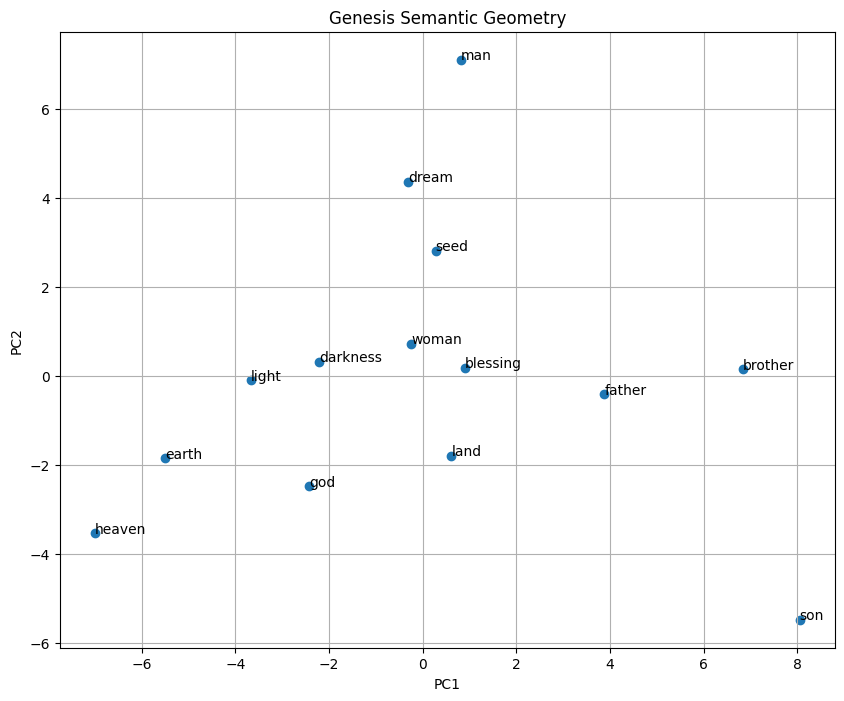

In [43]:
genesis_plot_words = [
    "god", "earth", "heaven", "light", "darkness",
    "man", "woman", "father", "son", "dream",
    "brother", "land", "blessing", "seed"
]

plot_words(genesis_plot_words, gen_embeddings, gen_word_to_id, "Genesis Semantic Geometry")

# Plot Shakespeare semantic field

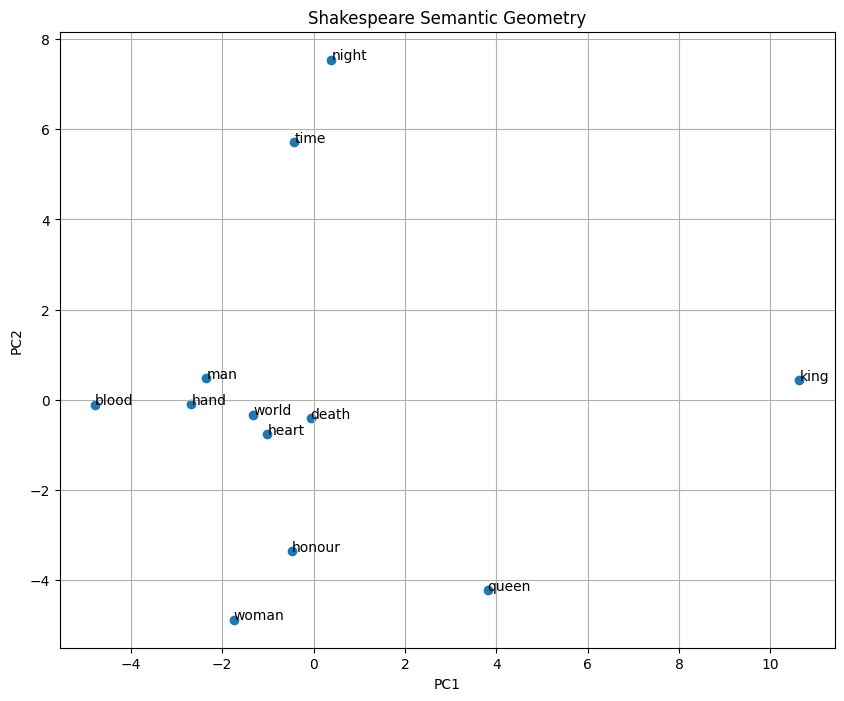

In [44]:
shakespeare_plot_words = [
    "king", "queen", "love", "death", "heart",
    "night", "man", "woman", "honour", "blood",
    "time", "world", "soul", "hand"
]

plot_words(shakespeare_plot_words, sha_embeddings, sha_word_to_id, "Shakespeare Semantic Geometry")

# Create comparison table

In [45]:
comparison_words = ["man", "father", "love"]

rows = []

for word in comparison_words:
    gen_neighbors = nearest_neighbors(word, gen_embeddings, gen_word_to_id, gen_id_to_word, top_n=5)
    sha_neighbors = nearest_neighbors(word, sha_embeddings, sha_word_to_id, sha_id_to_word, top_n=5)

    rows.append({
        "word": word,
        "genesis_neighbors": ", ".join([w for w, _ in gen_neighbors]),
        "shakespeare_neighbors": ", ".join([w for w, _ in sha_neighbors]),
    })

comparison_df = pd.DataFrame(rows)
comparison_df

,word,genesis_neighbors,shakespeare_neighbors
0,man,"one, a, each, child, him","euery, a, an, one, that's"
1,father,"words, brethren, isaac, spake, israel","mother, alas, hamlet, son, wife"
2,love,"savoury, meat, such, husband, soon",


# Inspect most frequent words

In [46]:
gen_freq_df = pd.DataFrame(gen_counts.most_common(20), columns=["word", "count"])
sha_freq_df = pd.DataFrame(sha_counts.most_common(20), columns=["word", "count"])

print("Genesis top words")
display(gen_freq_df)

print("Shakespeare top words")
display(sha_freq_df)

Genesis top words


,word,count
0,and,3678
1,the,2459
2,of,1366
3,his,653
4,he,652
5,to,612
6,in,600
7,unto,598
8,that,520
9,i,484


Shakespeare top words


,word,count
0,the,2221
1,and,2034
2,to,1512
3,of,1302
4,you,1115
5,a,1017
6,my,914
7,that,873
8,in,808
9,it,774


# Save embeddings

In [47]:
np.save("genesis_embeddings.npy", gen_embeddings)
np.save("shakespeare_embeddings.npy", sha_embeddings)

pd.DataFrame(gen_embeddings, index=gen_vocab).to_csv("genesis_embeddings.csv")
pd.DataFrame(sha_embeddings, index=sha_vocab).to_csv("shakespeare_embeddings.csv")

print("Embeddings saved.")

Embeddings saved.


# Save comparison results

In [48]:
comparison_df.to_csv("genesis_shakespeare_comparison.csv", index=False)
print("Comparison table saved.")

Comparison table saved.
